In [ ]:
import sys
import cv2

print("Python:", sys.executable)
print("OpenCV:", cv2.__file__)
print("Version:", cv2.__version__)
print("GOTURN:", hasattr(cv2, "TrackerGOTURN_create"))
print("Legacy GOTURN:", hasattr(cv2, "legacy") and hasattr(cv2.legacy, "TrackerGOTURN_create"))

Python: /opt/anaconda3/envs/opencv-env/bin/python
OpenCV: /opt/anaconda3/envs/opencv-env/lib/python3.14/site-packages/cv2/__init__.py
Version: 4.10.0
GOTURN: True
Legacy GOTURN: False


# Object Tracking

Object tracking is not the act of recognizing the object in every frame
- because in that case if there are multiple instances of the object, then the tracking would fail. 
Object tracking is the act of recognizing an instance of an object at that frame *and* predicting where that object will be in the consecutive frames.

We accomplish this through creating a motion model and an appearance model.
- Motion model takes in inputs such as the pixel coordinates and the velocity of the object detected -> for the general vicinity
- Appearance encodes what the object looks like and searches the returned area from the motion model to finetune the object position.

OpenCV's Tracker API has different models with different specialties
- Occlusion resistance -> TLD
- Predictable slow motion -> MEDIANFLOW
- Deep learning-based and most accurate -> GOTURN
- Fastest -> MOSSE

In [7]:
# Preview the video clip

from IPython.display import HTML

HTML("""
<video width="640" height="480" controls>
  <source src="../Videos/race_car.mp4" type="video/mp4">
</video>
""")


In [8]:
import cv2
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import urllib

input_video_path = "../Videos/race_car.mp4"

# Bounding box drawing functions
def drawingRectangles(frame, bbox): 
    upperleft = (int(bbox[0]), int(bbox[1]))
    lowerright = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
    cv2.rectangle(frame, upperleft, lowerright, (255, 0, 0), 2, 1)

def displayRectangle(frame, bbox):
    plt.figure(figsize=(20, 10))
    frame_copy = frame.copy()
    drawingRectangles(frame_copy, bbox)
    frame_rgb = cv2.cvtColor(frame_copy, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb); plt.axis('off'); plt.show()

def drawText(frame, text, location, color = (50, 170, 50)):
    cv2.putText(frame, text, location, cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)

So GOTURN isn't exposed with the Tracker API... I had to run opencv-contrib-python back to 4.10.0.84 to expose it. I don't know where it is expose in 5.0.0 though...

In [9]:
# Tracker type selector

tracker_types = [
    "BOOSTING",
    "MIL",
    "KCF",
    "CSRT",
    "TLD",
    "MEDIANFLOW",
    "GOTURN",
    "MOSSE",
]

# Change the index to change the tracker type
tracker_type = tracker_types[6]

if tracker_type == 'BOOSTING':
    tracker = cv2.legacy.TrackerBoosting_create()
elif tracker_type == 'MIL':
    tracker = cv2.TrackerMIL_create()
elif tracker_type == 'KCF':
    tracker = cv2.TrackerKCF_create()
elif tracker_type == 'TLD':
    tracker = cv2.legacy.TrackerTLD_create()
elif tracker_type == 'MEDIANFLOW':
    tracker = cv2.legacy.TrackerMedianFlow_create()
elif tracker_type == 'GOTURN':
    tracker = cv2.TrackerGOTURN_create()
elif tracker_type == "CSRT":
    tracker = cv2.TrackerCSRT_create()
elif tracker_type == "MOSSE":
    tracker = cv2.legacy.TrackerMOSSE_create()
else:
    tracker = None

In [10]:
# Set up Video input and output

video_read = cv2.VideoCapture(input_video_path)
read_success, frame = video_read.read()

# Catch all
if not video_read.isOpened() or not read_success:
    print("Could not open video")
    sys.exit()
else:
    width = int(video_read.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video_read.get(cv2.CAP_PROP_FRAME_HEIGHT))

output_video_path = "../Videos/race_car_" + tracker_type + ".mp4"
video_writer = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*'avc1'), 10, (width, height))

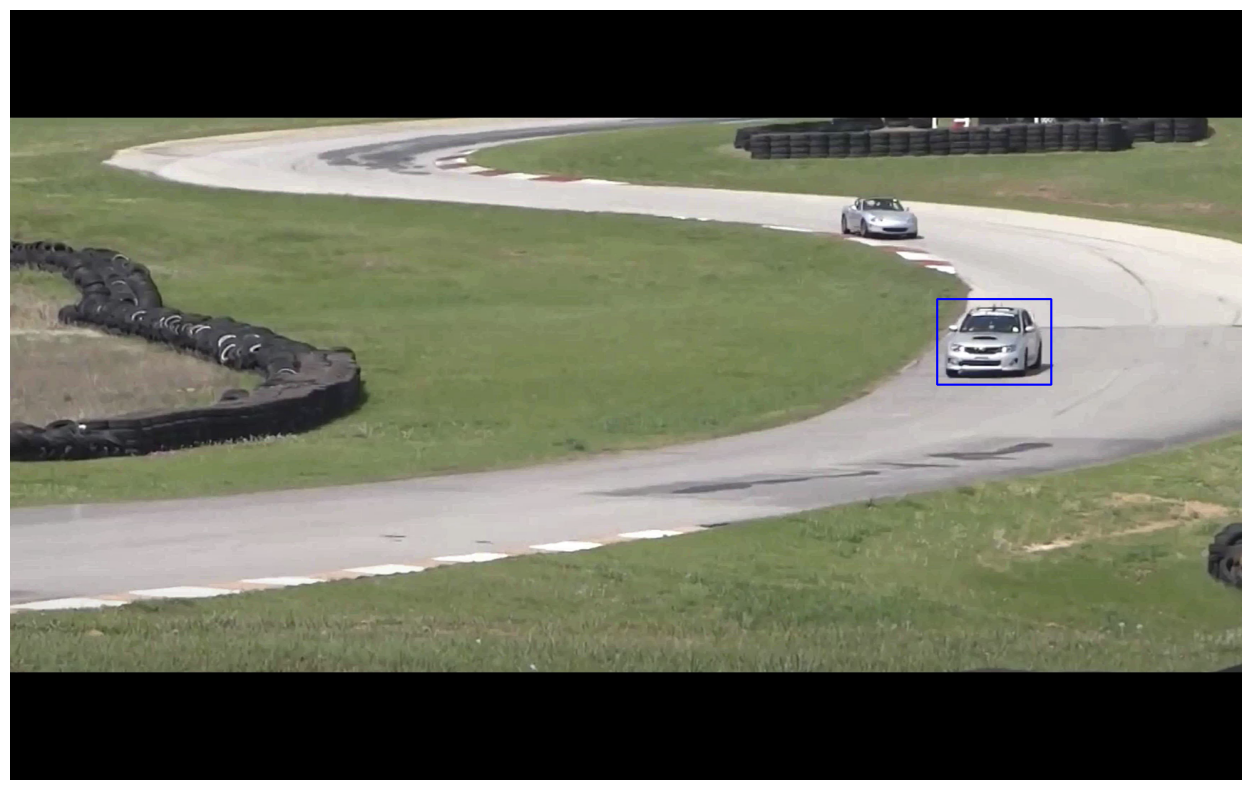

In [11]:
# Define bounding box
bbox = (1300, 405, 160, 120)  # x, y, width, height

displayRectangle(frame, bbox)

In [12]:
# Initialize tracker

init_success = tracker.init(frame, bbox)

while True:
    read_success, frame = video_read.read()
    if not read_success:
        break

    timer = cv2.getTickCount()

    read_success, bbox = tracker.update(frame)

    fps = cv2.getTickFrequency() / (cv2.getTickCount() - timer)

    if read_success:
        drawingRectangles(frame, bbox)
    else:
        drawText(frame, "Tracking failure detected", (80, 140), (0, 0, 255))

    drawText(frame, tracker_type + " Tracker", (80, 60))
    drawText(frame, "FPS : " + str(int(fps)), (80, 100))
    drawText(frame, "Bounding Box : " + str(bbox), (80, 180))

    video_writer.write(frame)

video_read.release()
video_writer.release()

In [13]:
HTML("""
<video width=1024 controls>
  <source src="../Videos/race_car_{}.mp4" type="video/mp4">
</video>
""".format(tracker_type))